In [1]:
# This notebook was executed in Google Colab using KaggleHub.
# For local execution, install kagglehub or skip the dataset download cell.

import kagglehub
meowmeowmeowmeowmeow_gtsrb_german_traffic_sign_path = kagglehub.dataset_download('meowmeowmeowmeowmeow/gtsrb-german-traffic-sign')

print('Data source import complete.')

Using Colab cache for faster access to the 'gtsrb-german-traffic-sign' dataset.
Data source import complete.


# Import Libraries

In [2]:
import numpy as np
import pandas as pd

import seaborn as sns
import os
import cv2
import matplotlib.pyplot as plt
import pathlib

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings("ignore")

In [3]:
data_dir="/kaggle/input/gtsrb-german-traffic-sign"
train_csv=pd.read_csv(os.path.join(data_dir,"Train.csv"))

In [4]:
train_csv

,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path
0,27,26,5,5,22,20,20,Train/20/00020_00000_00000.png
1,28,27,5,6,23,22,20,Train/20/00020_00000_00001.png
2,29,26,6,5,24,21,20,Train/20/00020_00000_00002.png
3,28,27,5,6,23,22,20,Train/20/00020_00000_00003.png
4,28,26,5,5,23,21,20,Train/20/00020_00000_00004.png
...,...,...,...,...,...,...,...,...
39204,52,56,5,6,47,51,42,Train/42/00042_00007_00025.png
39205,56,58,5,5,51,53,42,Train/42/00042_00007_00026.png
39206,58,62,5,6,53,57,42,Train/42/00042_00007_00027.png
39207,63,69,5,7,58,63,42,Train/42/00042_00007_00028.png


In [5]:
X,y=[],[]
for i ,row in train_csv.iterrows():
    image_path=os.path.join(data_dir,row["Path"])
    image=cv2.imread(image_path)
    image=cv2.resize(image,(32,32))
    X.append(image)
    y.append(row["ClassId"])

In [6]:
X=np.array(X)/255.0  #normalize images

In [7]:
y=to_categorical(y) # it one hot encodes class labels

# Train Test Split

In [8]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [9]:
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((31367, 32, 32, 3), (7842, 32, 32, 3), (31367, 43), (7842, 43))

In [10]:
datagen=ImageDataGenerator(rotation_range=10,zoom_range=0.15,width_shift_range=0.1,height_shift_range=0.1)

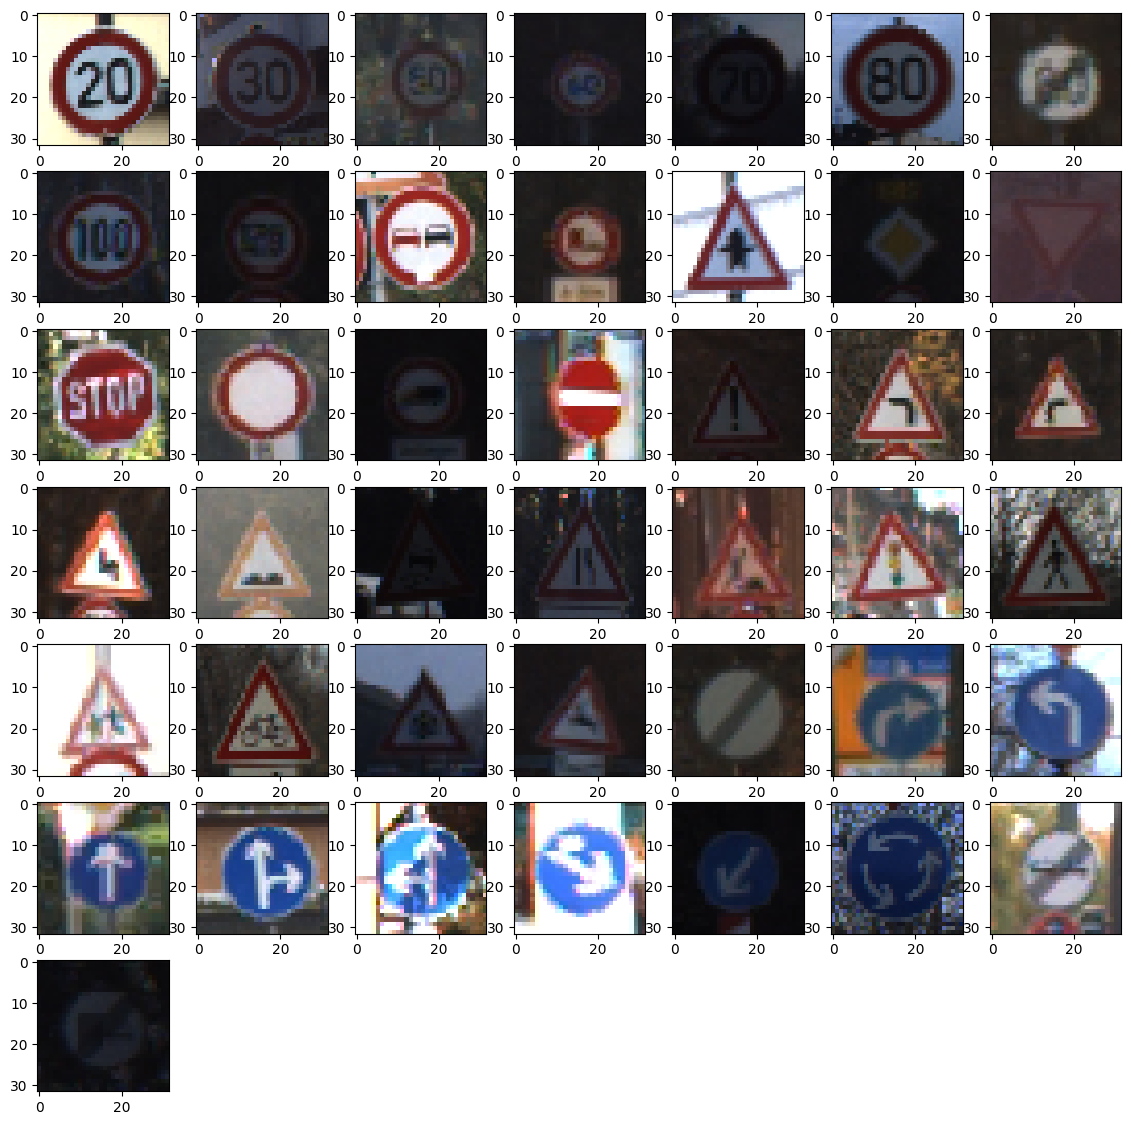

In [11]:
NUM_CATEGORIES=43
IMG_WIDTH,IMG_HEIGHT=32,32
train_path=os.path.join(data_dir,"Train")
img_dir=pathlib.Path(train_path)
plt.figure(figsize=(14,14))
for i in range(NUM_CATEGORIES):
  plt.subplot(7,7,i+1)
  sign=list(img_dir.glob(f"{i}/*"))[0]
  img=load_img(sign,target_size=(IMG_WIDTH,IMG_HEIGHT))
  plt.imshow(img)
plt.show()

# Model Architectur

In [12]:
model=Sequential([
    Conv2D(32,(3,3),activation="relu",input_shape=(32,32,3)),
    MaxPooling2D((2,2)),
    Conv2D(64,(3,3),activation="relu"),
    MaxPooling2D((2,2)),
    Conv2D(128,(3,3),activation="relu"),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(256,activation="relu"),
    Dropout(0.5),
    Dense(43,activation="softmax")

])

In [13]:
# Compile Model
model.compile(optimizer="adam",loss="categorical_crossentropy",metrics=["accuracy"])

# Training the model

In [14]:
history=model.fit(datagen.flow(X_train,y_train,batch_size=32),epochs=15,validation_data=(X_test,y_test))

Epoch 1/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 83s 81ms/step - accuracy: 0.2173 - loss: 2.8306 - val_accuracy: 0.7627 - val_loss: 0.8026
Epoch 2/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 81s 82ms/step - accuracy: 0.7203 - loss: 0.8570 - val_accuracy: 0.9184 - val_loss: 0.2607
Epoch 3/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 81s 82ms/step - accuracy: 0.8683 - loss: 0.4183 - val_accuracy: 0.9695 - val_loss: 0.1134
Epoch 4/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 81s 81ms/step - accuracy: 0.9144 - loss: 0.2641 - val_accuracy: 0.9718 - val_loss: 0.0978
Epoch 5/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 79s 81ms/step - accuracy: 0.9371 - loss: 0.2041 - val_accuracy: 0.9825 - val_loss: 0.0592
Epoch 6/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 82s 83ms/step - accuracy: 0.9526 - loss: 0.1514 - val_accuracy: 0.9846 - val_loss: 0.0537
Epoch 7/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 81s 83ms/step - accuracy: 0.9582 - loss: 0.1344 - val_accuracy: 0.9931 - val_loss: 0.0280
Epoch 8/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 82s 83ms/step - accuracy: 0.9639 - loss: 0.1073 - 

# Model Accuracy on test data

In [25]:
_,acc=model.evaluate(X_test,y_test)
print(f"Test Accuracy: {acc*100:.2f}%")

246/246 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.9904 - loss: 0.0329
Test Accuracy: 98.94%


Text(0.5, 1.0, 'Model Accuracy')

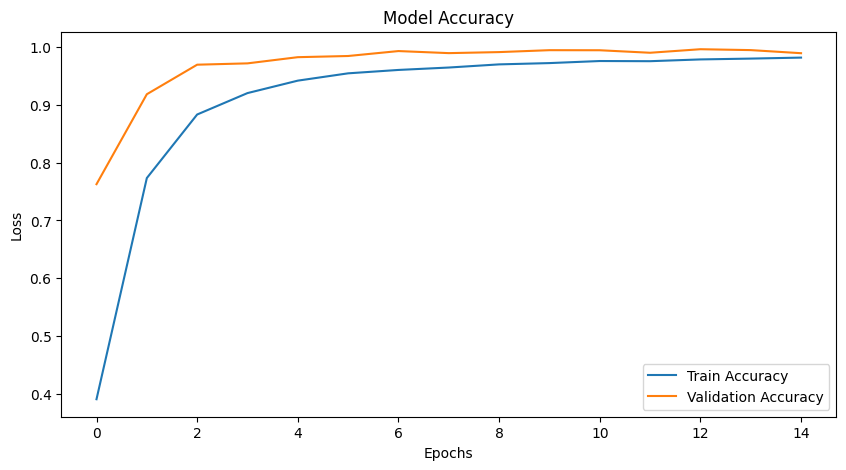

In [16]:
plt.figure(figsize=(10,5))
plt.plot(history.history["accuracy"],label="Train Accuracy")
plt.plot(history.history["val_accuracy"],label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Model Accuracy")

Text(0.5, 1.0, 'Model Loss')

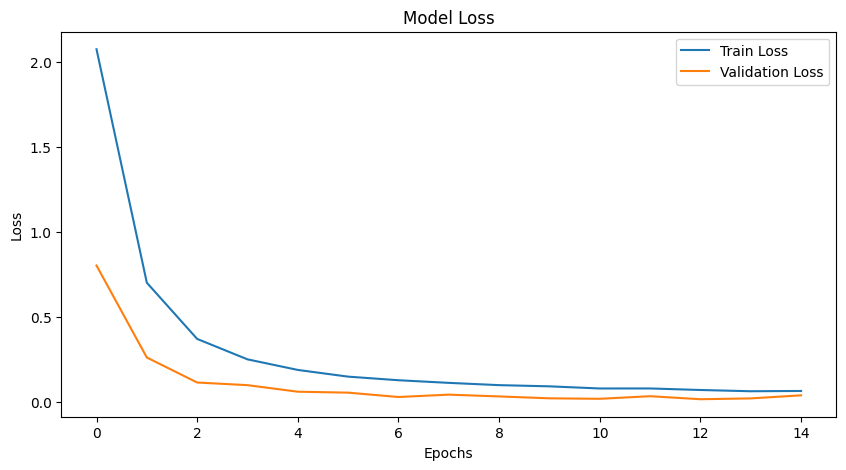

In [17]:
plt.figure(figsize=(10,5))
plt.plot(history.history["loss"],label="Train Loss")
plt.plot(history.history["val_loss"],label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Model Loss")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step


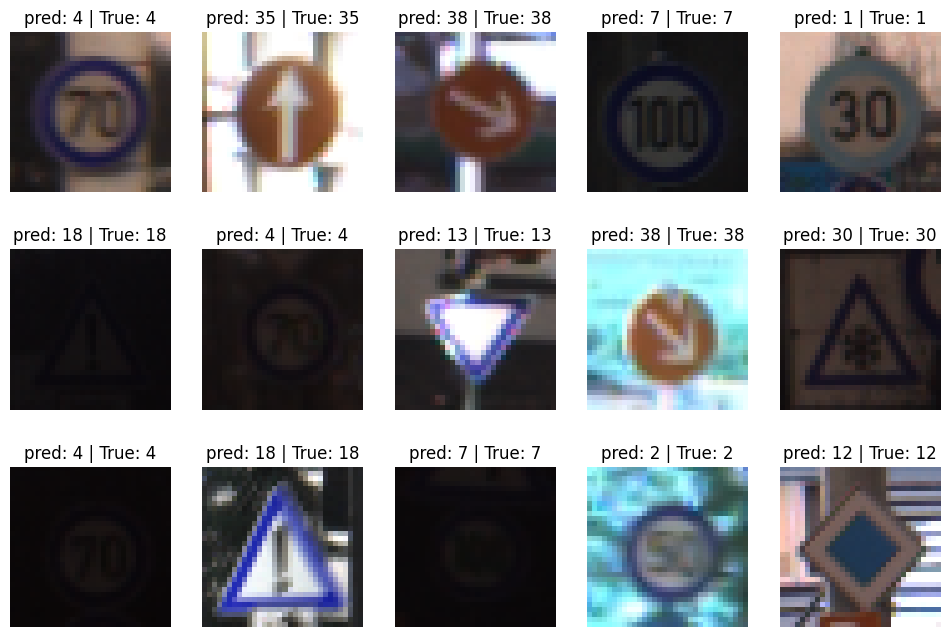

In [18]:
def predict_sample_images():
  fig,axes=plt.subplots(3,5 ,figsize=(12,8))
  for i,ax in enumerate(axes.flat):
    img=X_test[i]
    true_label=np.argmax(y_test[i])
    pred_label=np.argmax(model.predict(img.reshape(1,32,32,3)))
    ax.imshow(img)
    ax.set_title(f"pred: {pred_label} | True: {true_label}")
    ax.axis("off")
  plt.show()

predict_sample_images()

In [19]:
#label overview
classes={ 0:'Speed limit (20km/h)',
            1:'Speed limit (30km/h)',
            2:'Speed limit (50km/h)',
            3:'Speed limit (60km/h)',
            4:'Speed limit (70km/h)',
            5:'Speed limit (80km/h)',
            6:'End of speed limit (80km/h)',
            7:'Speed limit (100km/h)',
            8:'Speed limit (120km/h)',
            9:'No passing',
            10:'No passing veh over 3.5 tons',
            11:'Right-of-way at intersection',
            12:'Priority road',
            13:'Yield',
            14:'Stop',
            15:'No vehicles',
            16:'Veh > 3.5 tons prohibited',
            17:'No entry',
            18:'General caution',
            19:'Dangerous curve left',
            20:'Dangerous curve right',
            21:'Double curve',
            22:'Bumpy road',
            23:'Slippery road',
            24:'Road narrows on the right',
            25:'Road work',
            26:'Traffic signals',
            27:'Pedestrians',
            28:'Children crossing',
            29:'Bicycles crossing',
            30:'Beware of ice/snow',
            31:'Wild animals crossing',
            32:'End speed + passing limits',
            33:'Turn right ahead',
            34:'Turn left ahead',
            35:'Ahead only',
            36:'Go straight or right',
            37:'Go straight or left',
            38:'Keep right',
            39:'Keep left',
            40:'Roundabout mandatory',
            41:'End of no passing',
            42:'End no passing veh > 3.5 tons' }

In [26]:
model.save("gtsrb_model.h5")
print("Model saved successfully")

Model saved successfully


In [21]:
import json

with open("class_names.json", "w") as f:
    json.dump(classes, f)

print("Class names saved successfully")

Class names saved successfully


In [22]:
from google.colab import files

files.download("gtsrb_model.h5")
files.download("class_names.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [23]:
# streamlit deploy after github repository created then streamlit cloud to deploy

In [24]:
# https://gtsrb-app-i3idbs68e3qg64gfa6iulc.streamlit.app/  this is streamlit deploy link